this is the creation of my baseline model(linear Regression). 
i choose linear regression as base model as it is simple, easy to implement does not require much hypertuning.



In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [3]:
lr = LinearRegression()

In [4]:
#load dataset
sales_df = pd.read_parquet('../data/processed/06_model_dataset.parquet')
sales_df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 57473650 entries, 0 to 57473649
Data columns (total 32 columns):
 #   Column           Dtype         
---  ------           -----         
 0   index            int64         
 1   id               category      
 2   item_id          category      
 3   dept_id          category      
 4   cat_id           category      
 5   store_id         category      
 6   state_id         category      
 7   day              category      
 8   sales            uint16        
 9   date             datetime64[us]
 10  wm_yr_wk         uint16        
 11  weekday          category      
 12  wday             uint16        
 13  month            uint16        
 14  year             uint16        
 15  d                category      
 16  event_name_1     category      
 17  event_type_1     category      
 18  event_name_2     category      
 19  event_type_2     category      
 20  snap_CA          uint16        
 21  snap_TX          uint16        
 22  sna

In [5]:
X = sales_df.drop(columns=['sales'])
y = sales_df['sales']

In [6]:
X.head()

,index,id,item_id,dept_id,cat_id,store_id,state_id,day,date,wm_yr_wk,...,snap_WI,sell_price,is_weekend,is_month_start,is_month_end,lag_1,lag_7,lag_28,rolling_mean_7,rolling_mean_28
0,853720,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_29,2011-02-26,11105,...,0,NaN,1,0,0,0.0,0.0,0.0,0.0,0.0
1,853721,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_29,2011-02-26,11105,...,0,NaN,1,0,0,0.0,0.0,0.0,0.0,0.0
2,853722,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_29,2011-02-26,11105,...,0,NaN,1,0,0,0.0,0.0,0.0,0.0,0.0
3,853723,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_29,2011-02-26,11105,...,0,NaN,1,0,0,0.0,0.0,0.0,0.0,0.0
4,853724,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_29,2011-02-26,11105,...,0,NaN,1,0,0,0.0,0.0,0.0,0.0,0.0


numerical column will be used as feature for this basemodel. categorical column requires encoding for linear model training which would explode the matrix for this dataset, for now the linear regression model will be trained only on numerical data for simplicity
sell_price column has around 20% of null values which cant be ignored, but it create complications since we cant simply fill it with zero, for base model i will be ignoring price column 

In [7]:
cols_keep = [ 'month', 'year', 'wday', 'is_weekend', 'is_month_start', 'is_month_end', 'lag_1', 'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'snap_CA', 'snap_TX', 'snap_WI']
X = X[cols_keep]


In [8]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
month,57473650.0,6.423873,3.440770,1.0,3.0,6.000000,9.000000,12.000000
year,57473650.0,2013.241910,1.519404,2011.0,2012.0,2013.000000,2015.000000,2016.000000
wday,57473650.0,3.997347,2.000661,1.0,2.0,4.000000,6.000000,7.000000
is_weekend,57473650.0,0.286472,0.452113,0.0,0.0,0.000000,1.000000,1.000000
is_month_start,57473650.0,0.032891,0.178352,0.0,0.0,0.000000,0.000000,1.000000
is_month_end,57473650.0,0.032891,0.178352,0.0,0.0,0.000000,0.000000,1.000000
lag_1,57473650.0,1.129795,3.870335,0.0,0.0,0.000000,1.000000,763.000000
lag_7,57473650.0,1.128247,3.870027,0.0,0.0,0.000000,1.000000,763.000000
lag_28,57473650.0,1.122458,3.876982,0.0,0.0,0.000000,1.000000,763.000000
rolling_mean_7,57473650.0,1.128836,3.385342,0.0,0.0,0.285714,1.000000,602.857117


spliting the data into chronogical order 


In [9]:
# Split the data while keeping the chronological order
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    shuffle=False
)

In [10]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((45978920, 14), (11494730, 14), (45978920,), (11494730,))

In [11]:
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [12]:
rmse = root_mean_squared_error(y_test, y_pred)
print(f'Baseline Model RMSE: {rmse:.2f}')

Baseline Model RMSE: 2.09


## checking with standardised model

In [13]:
scaler = StandardScaler()

In [14]:
X_train_scaled = scaler.fit_transform(X_train)

In [15]:
X_test_scaled = scaler.transform(X_test)

In [16]:
lr.fit(X_train_scaled, y_train)
y_pred_scaled = lr.predict(X_test_scaled)
rmse_scaled = root_mean_squared_error(y_test, y_pred_scaled)
print(f'Baseline Model RMSE (scaled): {rmse_scaled:.2f}')

Baseline Model RMSE (scaled): 2.09


scaling does not have much difference in the rmse score 

In [17]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float32](14,)","[-0. , 0. , 0.02,..., 0.03, 0.02, 0.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['month','year','wday',...,'snap_CA','snap_TX','snap_WI']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float32,np.float32(-3.1425986)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [18]:
import os
import joblib

os.makedirs('../models', exist_ok=True)
joblib.dump(lr, '../models/baseline_linear_regression.joblib')

['../models/baseline_linear_regression.joblib']

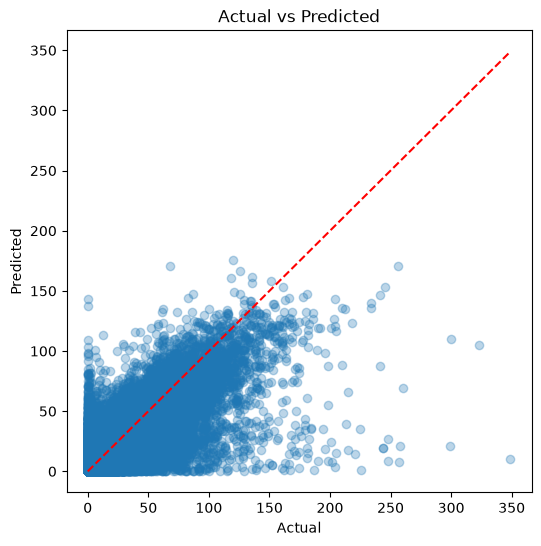

In [19]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()